# 재무비율 생성

In [2]:
import pandas as pd
import numpy as np

df = pd.read_parquet(r'데이터\기업_통합본_(todo)_ffill_정제.parquet')
df.columns.tolist()

['사업자등록번호',
 '회계년도',
 '회사명',
 '종업원',
 '설립일',
 '금감원등록번호',
 '외부감사기관',
 '통계청 한국표준산업분류 코드 11차(대분류)',
 '통계청 한국표준산업분류 11차(중분류)',
 '자산총계(요약)(백만원)',
 '유동자산(요약)(백만원)',
 '현금 및 현금성자산(요약)(백만원)',
 '매출채권(요약)(백만원)',
 '재고자산(요약)(백만원)',
 '비유동자산(요약)(백만원)',
 '유형자산(요약)(백만원)',
 '부채총계(요약)(백만원)',
 '유동부채(요약)(백만원)',
 '매입채무(요약)(백만원)',
 '단기차입금(요약)(백만원)',
 '유동성장기부채(요약)(백만원)',
 '사채(요약)(백만원)',
 '장기차입금(요약)(백만원)',
 '비유동부채(요약)(백만원)',
 '자본총계(요약)(백만원)',
 '자본금(요약)(백만원)',
 '자본잉여금(요약)(백만원)',
 '이익잉여금(요약)(백만원)',
 '매출액(요약)(백만원)',
 '매출원가(요약)(백만원)',
 '매출총이익(요약)(백만원)',
 '판매비와 관리비(요약)(백만원)',
 '영업이익(요약)(백만원)',
 '이자비용(요약)(백만원)',
 '당기순이익(요약)(백만원)',
 '법인세비용차감전(계속사업)손익(요약)(백만원)',
 '(계속사업손익)법인세비용(요약)(백만원)',
 '영업활동으로 인한 현금흐름(요약)(백만원)',
 '*감가상각비',
 '투자활동으로 인한 현금흐름(요약)(백만원)',
 '재무활동으로 인한 현금흐름(요약)(백만원)']

In [3]:
df.isna().sum()

사업자등록번호                        0
회계년도                           0
회사명                            0
종업원                            0
설립일                          335
금감원등록번호                        0
외부감사기관                        32
통계청 한국표준산업분류 코드 11차(대분류)       0
통계청 한국표준산업분류 11차(중분류)          0
자산총계(요약)(백만원)                 20
유동자산(요약)(백만원)                 20
현금 및 현금성자산(요약)(백만원)           20
매출채권(요약)(백만원)                 20
재고자산(요약)(백만원)                 20
비유동자산(요약)(백만원)                20
유형자산(요약)(백만원)                 20
부채총계(요약)(백만원)                 20
유동부채(요약)(백만원)                 20
매입채무(요약)(백만원)                 20
단기차입금(요약)(백만원)                20
유동성장기부채(요약)(백만원)              20
사채(요약)(백만원)                   20
장기차입금(요약)(백만원)                20
비유동부채(요약)(백만원)                20
자본총계(요약)(백만원)                 20
자본금(요약)(백만원)                  20
자본잉여금(요약)(백만원)                20
이익잉여금(요약)(백만원)                20
매출액(요약)(백만원)                  20
매출원가(요약)(백만원)                 20
매출총이익(요약)(

In [4]:
"""
재무비율 1~67번 생성 코드
- 입력: df (원본 40개 컬럼 그대로 유지)
- 출력: df에 재무비율 컬럼 직접 추가
- 기초 재무지표 컬럼명 변경 없음
"""

import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────
# 원본 컬럼명 alias (읽기 편의용 — df 컬럼명 절대 변경 안 함)
# ─────────────────────────────────────────────────────────────
ASSET      = "자산총계(요약)(백만원)"
CUR_ASSET  = "유동자산(요약)(백만원)"
CASH       = "현금 및 현금성자산(요약)(백만원)"
RECV       = "매출채권(요약)(백만원)"
INVEN      = "재고자산(요약)(백만원)"
NCUR_ASSET = "비유동자산(요약)(백만원)"
TANGIBLE   = "유형자산(요약)(백만원)"

LIAB       = "부채총계(요약)(백만원)"
CUR_LIAB   = "유동부채(요약)(백만원)"
AP         = "매입채무(요약)(백만원)"
ST_BORROW  = "단기차입금(요약)(백만원)"
CUR_LTD    = "유동성장기부채(요약)(백만원)"
BOND       = "사채(요약)(백만원)"
LT_BORROW  = "장기차입금(요약)(백만원)"
NCUR_LIAB  = "비유동부채(요약)(백만원)"

EQUITY     = "자본총계(요약)(백만원)"
CAP_STOCK  = "자본금(요약)(백만원)"
CAP_SUR    = "자본잉여금(요약)(백만원)"
RETAINED   = "이익잉여금(요약)(백만원)"

SALES      = "매출액(요약)(백만원)"
COGS       = "매출원가(요약)(백만원)"
GROSS      = "매출총이익(요약)(백만원)"
SGA        = "판매비와 관리비(요약)(백만원)"
SALARY     = "급료"
OP_INC     = "영업이익(요약)(백만원)"
INT_EXP    = "이자비용(요약)(백만원)"
NET_INC    = "당기순이익(요약)(백만원)"
EBT        = "법인세비용차감전(계속사업)손익(요약)(백만원)"
TAX        = "(계속사업손익)법인세비용(요약)(백만원)"

CFO        = "영업활동으로 인한 현금흐름(요약)(백만원)"
DEP        = "*감가상각비"

ID         = "사업자등록번호"
YEAR       = "회계년도"

# ─────────────────────────────────────────────────────────────
# 안전 나눗셈 함수
# ─────────────────────────────────────────────────────────────
def safe_div(num, denom, allow_neg_denom=False):
    """
    분모 = 0  → NaN
    allow_neg_denom=False (기본): 분모 ≤ 0 → NaN
    allow_neg_denom=True        : 분모 ≠ 0 → 계산 허용 (음수 분모 포함)
    """
    num   = pd.Series(num).reset_index(drop=True).astype(float)
    denom = pd.Series(denom).reset_index(drop=True).astype(float)
    result = np.full(len(num), np.nan)
    valid  = (denom != 0) if allow_neg_denom else (denom > 0)
    result[valid] = num.values[valid] / denom.values[valid]
    return pd.Series(result, index=num.index)

# ─────────────────────────────────────────────────────────────
# 부호전환 증가율 함수 (55·56·57·60·62·63번용)
# 전기=0 → NaN / 부호 전환 → NaN / 같은 부호끼리만 의미있음
# ─────────────────────────────────────────────────────────────
def growth_same_sign(cur, prev):
    cur  = pd.Series(cur).reset_index(drop=True).astype(float)
    prev = pd.Series(prev).reset_index(drop=True).astype(float)
    result = np.full(len(cur), np.nan)
    valid = (prev != 0) & (np.sign(cur) == np.sign(prev))
    result[valid] = (cur.values[valid] - prev.values[valid]) / np.abs(prev.values[valid])
    return pd.Series(result, index=cur.index)

# ═════════════════════════════════════════════════════════════
# STEP 1. 정렬 (기업별 연도순 — lag 계산 전제)
# ═════════════════════════════════════════════════════════════
df = df.sort_values([ID, YEAR]).reset_index(drop=True)

# ═════════════════════════════════════════════════════════════
# STEP 2. Lag(전기) 컬럼 생성
#   — 평균 분모/분자가 필요한 모든 항목의 기초값
#   — 임시 컬럼(_lag)은 마지막에 drop
# ═════════════════════════════════════════════════════════════
lag_map = {
    # 임시컬럼명        : 원본컬럼명
    "_lag_asset"      : ASSET,
    "_lag_cur_asset"  : CUR_ASSET,
    "_lag_ncur_asset" : NCUR_ASSET,
    "_lag_tangible"   : TANGIBLE,
    "_lag_liab"       : LIAB,
    "_lag_cur_liab"   : CUR_LIAB,
    "_lag_ap"         : AP,
    "_lag_recv"       : RECV,
    "_lag_inven"      : INVEN,
    "_lag_equity"     : EQUITY,
    # 성장성용 (전기 원시값)
    "_lag_sales"      : SALES,
    "_lag_op_inc"     : OP_INC,
    "_lag_net_inc"    : NET_INC,
    "_lag_cfo"        : CFO,
}

for lag_col, orig_col in lag_map.items():
    df[lag_col] = df.groupby(ID)[orig_col].shift(1)
    # ※ 첫 해(전기 없음): fillna 안 함 → NaN 유지
    #   (평균 분모 계산 시 NaN 전파 → 첫 해 비율 NaN 처리됨)
    #   성장성 지표는 전기값이 없으면 당연히 NaN이 맞음

# ─── 평균 분모/분자용 중간값 (기초+기말)/2 ─────────────────
avg_asset      = (df[ASSET]      + df["_lag_asset"])      / 2
avg_cur_asset  = (df[CUR_ASSET]  + df["_lag_cur_asset"])  / 2
avg_ncur_asset = (df[NCUR_ASSET] + df["_lag_ncur_asset"]) / 2
avg_tangible   = (df[TANGIBLE]   + df["_lag_tangible"])   / 2
avg_liab       = (df[LIAB]       + df["_lag_liab"])       / 2
avg_cur_liab   = (df[CUR_LIAB]   + df["_lag_cur_liab"])   / 2
avg_ap         = (df[AP]         + df["_lag_ap"])         / 2
avg_recv       = (df[RECV]       + df["_lag_recv"])       / 2
avg_inven      = (df[INVEN]      + df["_lag_inven"])      / 2
avg_equity     = (df[EQUITY]     + df["_lag_equity"])     / 2

# ═════════════════════════════════════════════════════════════
# STEP 3. 파생 중간변수
# ═════════════════════════════════════════════════════════════

# 총차입금 (당기·전기 모두 필요)
total_borrow = (
    df[ST_BORROW].fillna(0) + df[CUR_LTD].fillna(0)
    + df[BOND].fillna(0)    + df[LT_BORROW].fillna(0)
)
total_borrow_lag = (
    df.groupby(ID)[ST_BORROW].shift(1).fillna(0)
    + df.groupby(ID)[CUR_LTD].shift(1).fillna(0)
    + df.groupby(ID)[BOND].shift(1).fillna(0)
    + df.groupby(ID)[LT_BORROW].shift(1).fillna(0)
)

# 순차입금 = 총차입금 - 현금 (당기·전기)
net_borrow     = total_borrow     - df[CASH].fillna(0)
net_borrow_lag = total_borrow_lag - df.groupby(ID)[CASH].shift(1).fillna(0)

# 실효세율 (ROIC용): EBT≤0→0, 범위 벗어나면 0.22
eff_tax = np.where(
    df[EBT] <= 0, 0.0,
    np.clip(df[TAX] / df[EBT], 0, 1)
)
eff_tax = np.where(np.isnan(eff_tax), 0.22, eff_tax)

# 평균 투하자본 = ((기말자본+기말순차입금) + (기초자본+기초순차입금)) / 2
invested_capital = (
    (df[EQUITY]       + net_borrow)
    + (df["_lag_equity"] + net_borrow_lag)
) / 2

# EBITDA (57번 EBITDA증가율 선계산용)
ebitda     = df[OP_INC].fillna(0) + df[DEP].fillna(0)
ebitda_lag = df.groupby(ID)[OP_INC].shift(1).fillna(0) + \
             df.groupby(ID)[DEP].shift(1).fillna(0)

# NWC
nwc = df[CUR_ASSET].fillna(0) - df[CUR_LIAB].fillna(0)

# 당좌자산 근사 (유동자산 - 재고자산)
quick_asset = df[CUR_ASSET].fillna(0) - df[INVEN].fillna(0)

# FCF = CFO - 유형자산취득액
# 유형자산취득액 = 유형자산(기말) - 유형자산(기초) + 감가상각비
capex = (df[TANGIBLE] - df["_lag_tangible"].fillna(df[TANGIBLE])) + df[DEP].fillna(0)
fcf   = df[CFO].fillna(0) - capex
fcf_lag = df.groupby(ID)["_lag_cfo"].shift(0).fillna(0)  # placeholder; 재계산 아래에서
# FCF 전기값 (63번용): 전기 CFO - 전기 capex
capex_lag = (
    df["_lag_tangible"]
    - df.groupby(ID)[TANGIBLE].shift(2)      # 전전기 유형자산
    + df.groupby(ID)[DEP].shift(1).fillna(0) # 전기 감가상각비
)
fcf_lag = df["_lag_cfo"].fillna(0) - capex_lag.fillna(
    df["_lag_tangible"].fillna(0) - df["_lag_tangible"].fillna(0)  # 전전기 없으면 0 → NaN 전파
)

# ═════════════════════════════════════════════════════════════
# STEP 4. 재무비율 계산 (1~67번)
# ═════════════════════════════════════════════════════════════

# ── [안정성 — 부채] 1~7 ──────────────────────────────────────
# 1. 부채비율: 부채총계 / 자본총계  (자본>0)
df["부채비율"] = safe_div(df[LIAB], df[EQUITY])

# 2. 총부채비율: 부채총계 / 자산총계
df["총부채비율"] = safe_div(df[LIAB], df[ASSET])

# 3. 장기부채비율: 비유동부채 / 자본총계
df["장기부채비율"] = safe_div(df[NCUR_LIAB], df[EQUITY])

# 4. 장기부채의존도: 비유동부채 / 자산총계
df["장기부채의존도"] = safe_div(df[NCUR_LIAB], df[ASSET])

# 5. 차입금의존도: (단기차입금+유동성장기부채+사채+장기차입금) / 자산총계
df["차입금의존도"] = safe_div(total_borrow, df[ASSET])

# 6. 순차입금비율: (총차입금 - 현금) / 자본총계  (분자 음수 허용)
df["순차입금비율"] = safe_div(net_borrow, df[EQUITY], allow_neg_denom=False)

# 7. 금융부채비율: 총차입금 / 자본총계
df["금융부채비율"] = safe_div(total_borrow, df[EQUITY])

# ── [안정성 — 자본] 8~10 ─────────────────────────────────────
# 8. 자기자본비율: 자본총계 / 자산총계  (음수 허용)
df["자기자본비율"] = safe_div(df[EQUITY], df[ASSET], allow_neg_denom=False)

# 9. 유보율: (이익잉여금+자본잉여금) / 자본금   (음수 허용)
df["유보율"] = safe_div(
    df[RETAINED].fillna(0) + df[CAP_SUR].fillna(0),
    df[CAP_STOCK]
) 

# 10. 자본잠식률: (자본금 - 자본총계) / 자본금  (음수 허용)
df["자본잠식률"] = safe_div(
    df[CAP_STOCK] - df[EQUITY],
    df[CAP_STOCK], allow_neg_denom=False
)

# ── [안정성 — 유동성] 11~15 ──────────────────────────────────
# 11. 유동비율: 유동자산 / 유동부채
df["유동비율"] = safe_div(df[CUR_ASSET], df[CUR_LIAB])

# 12. 당좌비율: (유동자산 - 재고자산) / 유동부채  [당좌자산 근사]
df["당좌비율_추정"] = safe_div(quick_asset, df[CUR_LIAB])

# 13. 현금비율: 현금 / 유동부채
df["현금비율"] = safe_div(df[CASH], df[CUR_LIAB])

# 14. 순운전자본비율: (유동자산 - 유동부채) / 자산총계  (음수 허용)
df["순운전자본비율"] = safe_div(nwc, df[ASSET], allow_neg_denom=False)

# 15. 순운전자본회전율: 매출액 / NWC  (NWC>0만)
df["순운전자본회전율"] = safe_div(df[SALES], nwc)  # allow_neg_denom=False → NWC≤0 자동 NaN

# ── [안정성 — 이자상환] 16~17 ────────────────────────────────
# 16. 이자보상배율: 영업이익 / 이자비용  (음수 허용, 이자비용>0)
df["이자보상배율"] = safe_div(df[OP_INC], df[INT_EXP], allow_neg_denom=False)

# 17. 금융비용부담률: 이자비용 / 매출액
df["금융비용부담률"] = safe_div(df[INT_EXP], df[SALES])

# ── [안정성 — 자산구조] 18~21 ────────────────────────────────
# 18. 비유동비율: 비유동자산 / 자본총계
df["비유동비율"] = safe_div(df[NCUR_ASSET], df[EQUITY])

# 19. 비유동장기적합률: 비유동자산 / (자본총계 + 비유동부채)
df["비유동장기적합률"] = safe_div(
    df[NCUR_ASSET],
    df[EQUITY].fillna(0) + df[NCUR_LIAB].fillna(0)
)

# 20. 유형자산비율: 유형자산 / 자산총계
df["유형자산비율"] = safe_div(df[TANGIBLE], df[ASSET])

# 21. 유형자산부채비율: 유형자산 / 부채총계
df["유형자산부채비율"] = safe_div(df[TANGIBLE], df[LIAB])

# ── [수익성 — 자산·자본 대비] 22~25 ─────────────────────────
# 22. ROA: 당기순이익 / 평균자산  ★ (기초+기말)/2 평균 분모
df["ROA"] = safe_div(df[NET_INC], avg_asset, allow_neg_denom=False)

# 23. ROE: 당기순이익 / 평균자본  ★ (기초+기말)/2 평균 분모
df["ROE"] = safe_div(df[NET_INC], avg_equity, allow_neg_denom=False)

# 24. ROIC: NOPAT / 평균투하자본  ★ 분자·분모 모두 평균 구조
#   분자: 영업이익×(1-실효세율)  — 단기 flow 값이므로 평균 불필요
#   분모: (기초투하자본+기말투하자본)/2  ★ 평균 분모
df["ROIC"] = safe_div(
    df[OP_INC] * (1 - eff_tax),
    invested_capital,
    allow_neg_denom=False
)

# 25. 총자본영업이익률: 영업이익 / 평균자산  ★ (기초+기말)/2 평균 분모
df["총자본영업이익률"] = safe_div(df[OP_INC], avg_asset, allow_neg_denom=False)

# ── [수익성 — 매출 대비] 26~29 ───────────────────────────────
# 26. 매출총이익률: 매출총이익 / 매출액  (음수 허용)
df["매출총이익률"] = safe_div(df[GROSS], df[SALES], allow_neg_denom=False)

# 27. 영업이익률: 영업이익 / 매출액  (음수 허용)
df["영업이익률"] = safe_div(df[OP_INC], df[SALES], allow_neg_denom=False)

# 28. 순이익률: 당기순이익 / 매출액  (음수 허용)
df["순이익률"] = safe_div(df[NET_INC], df[SALES], allow_neg_denom=False)

# 29. EBITDA마진: (영업이익+감가상각비) / 매출액  (음수 허용)
df["EBITDA마진"] = safe_div(ebitda, df[SALES], allow_neg_denom=False)

# ── [수익성 — 현금 기반] 30~32 ───────────────────────────────
# 30. 영업현금흐름비율: CFO / 매출액  (음수 허용)
df["영업현금흐름비율"] = safe_div(df[CFO], df[SALES], allow_neg_denom=False)

# 31. 현금ROA: CFO / 평균자산  ★ (기초+기말)/2 평균 분모
df["현금ROA"] = safe_div(df[CFO], avg_asset, allow_neg_denom=False)

# 32. 현금ROE: CFO / 평균자본  ★ (기초+기말)/2 평균 분모
df["현금ROE"] = safe_div(df[CFO], avg_equity, allow_neg_denom=False)

# ── [수익성 — 비용 효율] 33~36 ───────────────────────────────
# 33. 매출원가율: 매출원가 / 매출액
df["매출원가율"] = safe_div(df[COGS], df[SALES])

# 34. 판관비율: 판관비 / 매출액
df["판관비율"] = safe_div(df[SGA], df[SALES])


# 36. 감가상각비율: 감가상각비 / 매출액
df["감가상각비율"] = safe_div(df[DEP].fillna(0), df[SALES])

# ── [활동성 — 자산 회전] 37~42 ───────────────────────────────
# 37. 총자산회전율: 매출액 / 평균자산  ★ (기초+기말)/2 평균 분모
df["총자산회전율"] = safe_div(df[SALES], avg_asset)

# 38. 유동자산회전율: 매출액 / 평균유동자산  ★ (기초+기말)/2 평균 분모
df["유동자산회전율"] = safe_div(df[SALES], avg_cur_asset)

# 39. 비유동자산회전율: 매출액 / 평균비유동자산  ★ (기초+기말)/2 평균 분모
df["비유동자산회전율"] = safe_div(df[SALES], avg_ncur_asset)

# 40. 유형자산회전율: 매출액 / 평균유형자산  ★ (기초+기말)/2 평균 분모
df["유형자산회전율"] = safe_div(df[SALES], avg_tangible)

# 41. 자기자본회전율: 매출액 / 평균자본  ★ (기초+기말)/2 평균 분모
df["자기자본회전율"] = safe_div(df[SALES], avg_equity)

# 42. 투하자본회전율: 매출액 / 평균투하자본  ★ (기초+기말)/2 평균 분모
df["투하자본회전율"] = safe_div(df[SALES], invested_capital)

# ── [활동성 — 운전자본 순환] 43~49 ──────────────────────────
# 43. 매출채권회전율: 매출액 / 평균매출채권  ★ (기초+기말)/2 평균 분모
df["매출채권회전율"] = safe_div(df[SALES], avg_recv)

# 44. 매출채권회수기간: 365 / 매출채권회전율
df["매출채권회수기간"] = safe_div(
    pd.Series(365.0, index=df.index),
    df["매출채권회전율"]
)

# 45. 재고자산회전율: 매출원가 / 평균재고자산  ★ (기초+기말)/2 평균 분모
df["재고자산회전율"] = safe_div(df[COGS], avg_inven)

# 46. 재고자산보유기간: 365 / 재고자산회전율
df["재고자산보유기간"] = safe_div(
    pd.Series(365.0, index=df.index),
    df["재고자산회전율"]
)

# 47. 매입채무회전율: 매출원가 / 평균매입채무  ★ (기초+기말)/2 평균 분모
df["매입채무회전율"] = safe_div(df[COGS], avg_ap)

# 48. 매입채무지급기간: 365 / 매입채무회전율
df["매입채무지급기간"] = safe_div(
    pd.Series(365.0, index=df.index),
    df["매입채무회전율"]
)

# 49. 현금전환주기(CCC): 매출채권회수기간 + 재고보유기간 - 매입채무지급기간  (음수 허용)
df["현금전환주기_CCC"] = (
    df["매출채권회수기간"].fillna(0)
    + df["재고자산보유기간"].fillna(0)
    - df["매입채무지급기간"].fillna(0)
)
# 셋 중 하나라도 NaN이면 CCC도 NaN
mask_ccc_nan = (
    df["매출채권회수기간"].isna()
    | df["재고자산보유기간"].isna()
    | df["매입채무지급기간"].isna()
)
df.loc[mask_ccc_nan, "현금전환주기_CCC"] = np.nan

# ── [활동성 — 현금흐름] 50~53 ────────────────────────────────
# 50. 영업CF/유동부채: CFO / 평균유동부채  ★ (기초+기말)/2 평균 분모
df["영업CF_유동부채"] = safe_div(df[CFO], avg_cur_liab, allow_neg_denom=False)

# 51. 영업CF/총부채: CFO / 평균부채총계  ★ (기초+기말)/2 평균 분모
df["영업CF_총부채"] = safe_div(df[CFO], avg_liab, allow_neg_denom=False)

# 52. FCF = CFO - 유형자산취득액
#   유형자산취득액 = 유형자산(기말) - 유형자산(기초) + 감가상각비
df["FCF"] = fcf

# 53. FCF/총자산: FCF / 자산총계  (음수 허용, 기말 자산총계 사용)
df["FCF_총자산"] = safe_div(df["FCF"], df[ASSET], allow_neg_denom=False)

# ── [성장성 — 매출] 54 ───────────────────────────────────────
# 54. 매출액증가율: (당기 - 전기) / 전기 매출액
#     전기=0 → NaN (safe_div)
df["매출액증가율"] = safe_div(
    df[SALES] - df["_lag_sales"],
    df["_lag_sales"]
)

# ── [성장성 — 이익] 55~57 ────────────────────────────────────
# 부호전환(흑자↔적자) → NaN / 전기=0 → NaN
# 55. 영업이익증가율
df["영업이익증가율"] = growth_same_sign(df[OP_INC], df["_lag_op_inc"])

# 56. 순이익증가율
df["순이익증가율"] = growth_same_sign(df[NET_INC], df["_lag_net_inc"])

# 57. EBITDA증가율
df["EBITDA증가율"] = growth_same_sign(ebitda, ebitda_lag)

# ── [성장성 — 자산·자본] 58~61 ───────────────────────────────
# 58. 총자산증가율: 자산총계는 항상 양수 → safe_div
df["총자산증가율"] = safe_div(
    df[ASSET] - df["_lag_asset"],
    df["_lag_asset"]
)

# 59. 유형자산증가율: 유형자산은 항상 양수 → safe_div
df["유형자산증가율"] = safe_div(
    df[TANGIBLE] - df["_lag_tangible"],
    df["_lag_tangible"]
)

# 60. 자기자본증가율: 자본총계 음수(자본잠식) 가능 → 부호전환 NaN
df["자기자본증가율"] = growth_same_sign(df[EQUITY], df["_lag_equity"])

# 61. 부채증가율: 부채총계는 항상 양수 → safe_div
df["부채증가율"] = safe_div(
    df[LIAB] - df["_lag_liab"],
    df["_lag_liab"]
)

# ── [성장성 — 현금흐름] 62~63 ────────────────────────────────
# 62. 영업현금흐름증가율: CFO 음수 가능 → 부호전환 NaN
df["영업현금흐름증가율"] = growth_same_sign(df[CFO], df["_lag_cfo"])

# 63. FCF증가율: FCF 음수 가능 → 부호전환 NaN
df["FCF증가율"] = growth_same_sign(fcf, fcf_lag)

# ── [성장성 — 추세 YoY 변화] 64~67 ──────────────────────────
# 64. ROA변화
df["ROA변화"] = df["ROA"] - df.groupby(ID)["ROA"].shift(1)

# 65. 영업이익률변화
df["영업이익률변화"] = df["영업이익률"] - df.groupby(ID)["영업이익률"].shift(1)

# 66. 부채비율변화
df["부채비율변화"] = df["부채비율"] - df.groupby(ID)["부채비율"].shift(1)

# 67. 유동비율변화
df["유동비율변화"] = df["유동비율"] - df.groupby(ID)["유동비율"].shift(1)

# ═══════════════════════════════════════════════════════
# 증가율 NaN 처리 — 0 대체
# NaN 발생 케이스:
#   safe_div  계열 → 전기=0
#   growth_same_sign 계열 → 전기=0 or 부호전환
#   변화율 계열 → 첫 연도 (전기값 없음)
# ═══════════════════════════════════════════════════════

growth_cols = [
    "매출액증가율",
    "영업이익증가율", "순이익증가율", "EBITDA증가율",
    "총자산증가율", "유형자산증가율", "자기자본증가율", "부채증가율",
    "영업현금흐름증가율", "FCF증가율",
    "ROA변화", "영업이익률변화", "부채비율변화", "유동비율변화",
]

print("=" * 60)
print("📊 증가율 NaN 처리 (→ 0 대체)")
print("=" * 60)

for col in growth_cols:
    nan_count = df[col].isnull().sum()
    if nan_count == 0:
        print(f"  ✅ {col}: NaN 없음 — 스킵")
        continue
    df[col] = df[col].fillna(0)
    print(f"  {col:<22} | NaN {nan_count:>6,}개 → 0 대체")

print("\n" + "=" * 60)
print("✅ 처리 후 잔여 NaN")
print("=" * 60)
remaining = df[growth_cols].isnull().sum()
remaining = remaining[remaining > 0]
print("  잔여 NaN 없음" if len(remaining) == 0 else remaining.to_string())

# ═════════════════════════════════════════════════════════════
# STEP 5. 임시 Lag 컬럼 제거
# ═════════════════════════════════════════════════════════════
df.drop(columns=list(lag_map.keys()), inplace=True)

# ═════════════════════════════════════════════════════════════
# 검토 출력
# ═════════════════════════════════════════════════════════════
ratio_cols = [
    # 안정성
    "부채비율","총부채비율","장기부채비율","장기부채의존도","차입금의존도",
    "순차입금비율","금융부채비율",
    "자기자본비율","유보율","자본잠식률",
    "유동비율","당좌비율_추정","현금비율","순운전자본비율","순운전자본회전율",
    "이자보상배율","금융비용부담률",
    "비유동비율","비유동장기적합률","유형자산비율","유형자산부채비율",
    # 수익성
    "ROA","ROE","ROIC","총자본영업이익률",
    "매출총이익률","영업이익률","순이익률","EBITDA마진",
    "영업현금흐름비율","현금ROA","현금ROE",
    "매출원가율","판관비율","인건비율","감가상각비율",
    # 활동성
    "총자산회전율","유동자산회전율","비유동자산회전율","유형자산회전율",
    "자기자본회전율","투하자본회전율",
    "매출채권회전율","매출채권회수기간",
    "재고자산회전율","재고자산보유기간",
    "매입채무회전율","매입채무지급기간","현금전환주기_CCC",
    "영업CF_유동부채","영업CF_총부채",
    "FCF","FCF_총자산",
    # 성장성
    "매출액증가율",
    "영업이익증가율","순이익증가율","EBITDA증가율",
    "총자산증가율","유형자산증가율","자기자본증가율","부채증가율",
    "영업현금흐름증가율","FCF증가율",
    "ROA변화","영업이익률변화","부채비율변화","유동비율변화",
]

print("=" * 60)
print(f"✅ 재무비율 생성 완료: {len(ratio_cols)}개")
print(f"   전체 열: {df.shape[1]} | 전체 행: {df.shape[0]:,}")
print()

# ── 평균 분모/분자 사용 비율 검토 ──────────────────────────
print("=" * 60)
print("📋 평균 분모/분자 사용 비율 검토 (★ 표시)")
print("-" * 60)
avg_check = {
    "22. ROA"           : "분모: avg_asset = (기초자산+기말자산)/2 ✅",
    "23. ROE"           : "분모: avg_equity = (기초자본+기말자본)/2 ✅",
    "24. ROIC"          : "분모: invested_capital = (기초투하자본+기말투하자본)/2 ✅",
    "25. 총자본영업이익률": "분모: avg_asset = (기초자산+기말자산)/2 ✅",
    "31. 현금ROA"       : "분모: avg_asset = (기초자산+기말자산)/2 ✅",
    "32. 현금ROE"       : "분모: avg_equity = (기초자본+기말자본)/2 ✅",
    "37. 총자산회전율"  : "분모: avg_asset = (기초자산+기말자산)/2 ✅",
    "38. 유동자산회전율": "분모: avg_cur_asset = (기초유동자산+기말유동자산)/2 ✅",
    "39. 비유동자산회전율":"분모: avg_ncur_asset = (기초비유동자산+기말비유동자산)/2 ✅",
    "40. 유형자산회전율": "분모: avg_tangible = (기초유형자산+기말유형자산)/2 ✅",
    "41. 자기자본회전율": "분모: avg_equity = (기초자본+기말자본)/2 ✅",
    "42. 투하자본회전율": "분모: invested_capital = (기초투하자본+기말투하자본)/2 ✅",
    "43. 매출채권회전율": "분모: avg_recv = (기초매출채권+기말매출채권)/2 ✅",
    "45. 재고자산회전율": "분모: avg_inven = (기초재고자산+기말재고자산)/2 ✅",
    "47. 매입채무회전율": "분모: avg_ap = (기초매입채무+기말매입채무)/2 ✅",
    "50. 영업CF/유동부채": "분모: avg_cur_liab = (기초유동부채+기말유동부채)/2 ✅",
    "51. 영업CF/총부채"  : "분모: avg_liab = (기초부채총계+기말부채총계)/2 ✅",
}
for ratio, desc in avg_check.items():
    print(f"  {ratio:20s} → {desc}")

print()
print("📋 평균 불필요 비율 (시점값 분모 사용) — 정의표 기준")
no_avg = [
    "1~7 안정성-부채 (시점값 분모)",
    "8~10 안정성-자본 (시점값 분모)",
    "11~15 안정성-유동성 (시점값 분모, 단 NWC는 당기 유동자산-유동부채)",
    "16~17 안정성-이자 (시점값 분모)",
    "18~21 안정성-자산구조 (시점값 분모)",
    "26~30 수익성-매출 (매출액 = flow, 평균 불필요)",
    "33~36 수익성-비용 (매출액 = flow, 평균 불필요)",
    "52~53 FCF (flow 지표)",
    "54~63 성장성 (전기값과 당기값 직접 비교)",
    "64~67 YoY 변화 (비율 차분, 평균 불필요)",
]
for item in no_avg:
    print(f"  ✅ {item}")

print()
print("📊 주요 비율 기술통계:")
key = ["ROA","ROE","총자산회전율","매출채권회전율","매출액증가율","부채비율변화"]
print(df[key].describe().round(4).to_string())

📊 증가율 NaN 처리 (→ 0 대체)
  매출액증가율                 | NaN 68,336개 → 0 대체
  영업이익증가율                | NaN 118,649개 → 0 대체
  순이익증가율                 | NaN 131,132개 → 0 대체
  EBITDA증가율              | NaN 106,546개 → 0 대체
  총자산증가율                 | NaN 50,365개 → 0 대체
  유형자산증가율                | NaN 72,741개 → 0 대체
  자기자본증가율                | NaN 67,567개 → 0 대체
  부채증가율                  | NaN 50,530개 → 0 대체
  영업현금흐름증가율              | NaN 167,888개 → 0 대체
  FCF증가율                 | NaN 195,770개 → 0 대체
  ROA변화                  | NaN 100,702개 → 0 대체
  영업이익률변화                | NaN 71,213개 → 0 대체
  부채비율변화                 | NaN 97,612개 → 0 대체
  유동비율변화                 | NaN 50,957개 → 0 대체

✅ 처리 후 잔여 NaN
  잔여 NaN 없음
✅ 재무비율 생성 완료: 67개
   전체 열: 107 | 전체 행: 407,928

📋 평균 분모/분자 사용 비율 검토 (★ 표시)
------------------------------------------------------------
  22. ROA              → 분모: avg_asset = (기초자산+기말자산)/2 ✅
  23. ROE              → 분모: avg_equity = (기초자본+기말자본)/2 ✅
  24. ROIC             → 분모: invested_capital = (기

In [5]:
df.describe()

,회계년도,종업원,금감원등록번호,통계청 한국표준산업분류 코드 11차(대분류),자산총계(요약)(백만원),유동자산(요약)(백만원),현금 및 현금성자산(요약)(백만원),매출채권(요약)(백만원),재고자산(요약)(백만원),비유동자산(요약)(백만원),...,총자산증가율,유형자산증가율,자기자본증가율,부채증가율,영업현금흐름증가율,FCF증가율,ROA변화,영업이익률변화,부채비율변화,유동비율변화
count,407928.000000,407928.000000,4.079280e+05,407928.000000,4.079080e+05,4.079080e+05,4.079080e+05,4.079080e+05,4.079080e+05,4.079080e+05,...,407928.000000,407928.000000,407928.000000,407928.000000,407928.000000,407928.000000,407928.000000,407928.000000,407928.000000,407928.000000
mean,2017.956968,140.468129,8.657706e+05,42.963329,1.850512e+05,7.254656e+04,1.294261e+04,2.114958e+04,1.917064e+04,1.059750e+05,...,0.199751,9.144406,0.338298,1.463713,0.416779,-1.001551,-0.004127,-0.092869,-1.176891,-2.923927
std,4.178992,1154.443971,4.549339e+05,20.387766,3.249628e+06,1.231360e+06,2.623812e+05,3.062491e+05,2.803602e+05,1.928346e+06,...,24.907592,923.487865,37.797779,345.694330,101.860060,150.573241,0.669708,62.920270,290.591131,509.259397
min,2010.000000,0.000000,1.000900e+05,1.000000,-4.100000e+01,-4.800000e+01,-1.106000e+03,-5.630000e+02,-3.010000e+02,-1.960000e+02,...,-1.003249,-1.000000,-7275.000000,-1.000000,-56712.000000,-56712.000000,-265.839754,-18898.000000,-84412.766917,-218823.713846
25%,2015.000000,2.000000,5.100200e+05,26.000000,1.460000e+04,4.576000e+03,1.800000e+02,2.070000e+02,0.000000e+00,5.280000e+03,...,-0.032756,-0.040871,-0.014326,-0.070644,-0.107329,-0.025051,-0.017978,-0.025463,-0.176916,-0.152827
50%,2018.000000,29.000000,8.744320e+05,41.000000,2.400400e+04,1.071700e+04,9.820000e+02,2.115000e+03,1.323000e+03,1.160600e+04,...,0.004976,0.000000,0.019876,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2022.000000,87.000000,1.215968e+06,62.000000,5.371900e+04,2.490500e+04,3.731000e+03,6.408000e+03,6.130000e+03,2.663700e+04,...,0.117564,0.050633,0.141666,0.134201,0.201107,0.064461,0.011717,0.020106,0.063266,0.153361
max,2024.000000,128881.000000,1.869288e+06,98.000000,5.145319e+08,2.270623e+08,6.908089e+07,5.324605e+07,5.218787e+07,2.874697e+08,...,8180.000000,461603.750000,12119.000000,205806.000000,9615.000000,12546.000000,269.399973,8493.584923,34487.600000,91948.147213


In [6]:
"""
타겟 라벨 인코딩: 이자보상배율(ICR) < 1 이 3년 연속인 기업
- 3년째 되는 해: 부실라벨 = 1
- 최초 부실 확정 연도 이후 행 전부 제거 (확정 연도 포함 유지)
- 정상 기업: 부실라벨 = 0

※ 전제: df에 '이자보상배율' 컬럼이 이미 존재해야 함 (16번 비율 선계산 필요)
   ICR이 NaN인 해(무차입 기업 등)는 연속 카운트 끊김 처리


STEP 1. 기업별 연도순 정렬
STEP 2. ICR < 1 연속 연수 카운트 (NaN이면 카운트 리셋)
STEP 3. 연속 3년째 → 부실라벨 = 1
STEP 4. 기업별 최초 부실 확정 연도 추출
STEP 5. 확정 연도 이후 행 제거 (확정 연도 행은 유지)
STEP 6. 임시 컬럼 정리
"""

import pandas as pd
import numpy as np

ID   = "사업자등록번호"
YEAR = "회계년도"
ICR  = "이자보상배율"

# ─────────────────────────────────────────────────────────────
# STEP 1. 정렬
# ─────────────────────────────────────────────────────────────
df = df.sort_values([ID, YEAR]).reset_index(drop=True)

# ─────────────────────────────────────────────────────────────
# STEP 2. ICR < 1 연속 연수 카운트 (기업별)
#   - ICR < 1: True → 카운트 +1
#   - ICR >= 1 또는 NaN: False → 카운트 0 리셋
# ─────────────────────────────────────────────────────────────
def consecutive_below1(series):
    """ICR < 1이 몇 년 연속인지 카운트 (NaN은 False 처리 → 카운트 끊김)"""
    result, c = [], 0
    for v in series:
        if pd.notna(v) and v < 1:
            c += 1
        else:
            c = 0
        result.append(c)
    return result

df["_consec_icr"] = df.groupby(ID)[ICR].transform(consecutive_below1)

# ─────────────────────────────────────────────────────────────
# STEP 3. 연속 3년째 = 부실 확정 → 라벨 1
# ─────────────────────────────────────────────────────────────
df["부실라벨_ICR3년"] = (df["_consec_icr"] >= 3).astype(int)

# ─────────────────────────────────────────────────────────────
# STEP 4. 기업별 최초 부실 확정 연도 추출
# ─────────────────────────────────────────────────────────────
first_insol = (
    df[df["부실라벨_ICR3년"] == 1]
    .groupby(ID)[YEAR]
    .min()
    .rename("_first_insol_year")
)
df = df.merge(first_insol, on=ID, how="left")

# ─────────────────────────────────────────────────────────────
# STEP 5. 최초 부실 확정 연도 이후 행 제거
#   - 부실 없는 기업(_first_insol_year=NaN): 전체 유지
#   - 부실 있는 기업: 확정 연도까지만 유지, 그 이후 제거
# ─────────────────────────────────────────────────────────────
before = len(df)

df = df[
    df["_first_insol_year"].isna() |
    (df[YEAR] <= df["_first_insol_year"])
].copy()

after = len(df)

# ─────────────────────────────────────────────────────────────
# STEP 6. 임시 컬럼 제거
# ─────────────────────────────────────────────────────────────
df.drop(columns=["_consec_icr", "_first_insol_year"], inplace=True)

# ─────────────────────────────────────────────────────────────
# 결과 확인
# ─────────────────────────────────────────────────────────────
n_insol  = (df["부실라벨_ICR3년"] == 1).sum()
n_normal = (df["부실라벨_ICR3년"] == 0).sum()
removed  = before - after

print("=" * 50)
print("✅ 타겟 라벨 인코딩 완료")
print(f"   정상(0): {n_normal:,}건")
print(f"   부실(1): {n_insol:,}건  ({n_insol / (n_insol + n_normal) * 100:.2f}%)")
print(f"   최초 부실 이후 제거 행: {removed:,}행")
print(f"   최종 행수: {after:,}행")
print("=" * 50)

✅ 타겟 라벨 인코딩 완료
   정상(0): 325,400건
   부실(1): 18,010건  (5.24%)
   최초 부실 이후 제거 행: 64,518행
   최종 행수: 343,410행


In [7]:
df.to_parquet(
    r"C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\데이터\3,4번. 재무비율 생성+라벨 생성.parquet",
    engine="pyarrow",
    compression="snappy"
)

사용 폰트: Malgun Gothic
저장: histogram_numeric.png


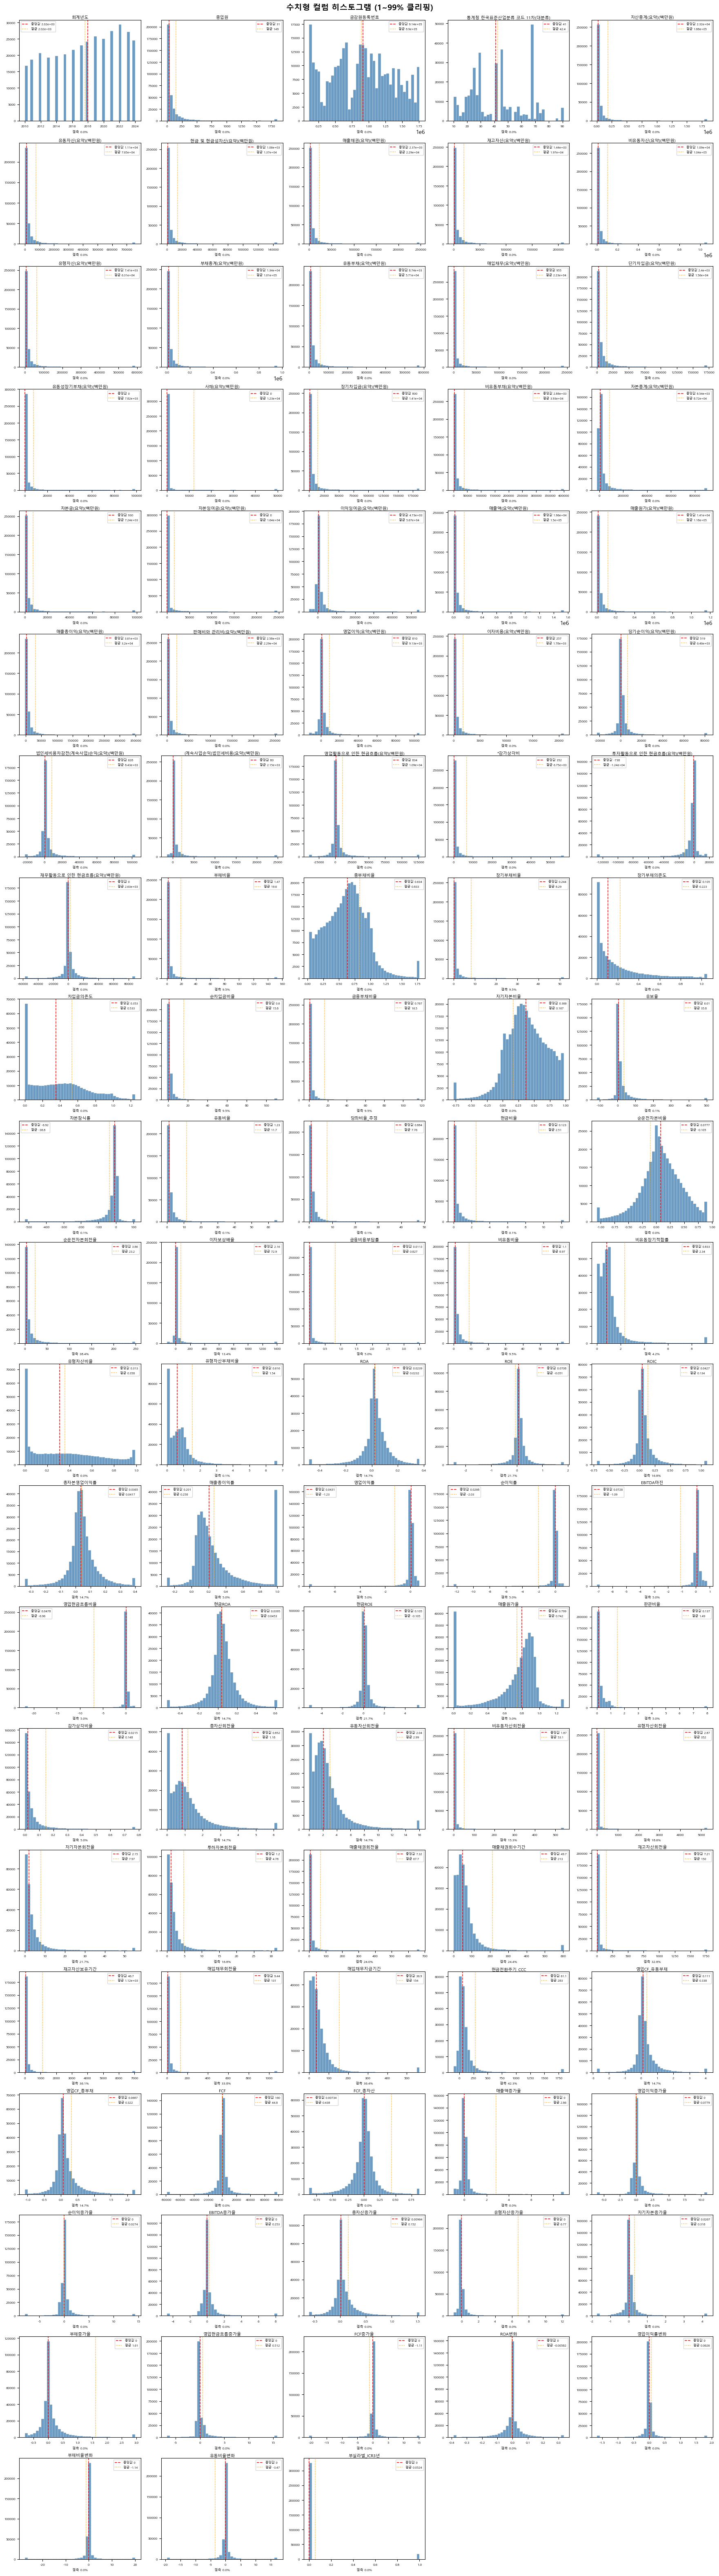

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 자동 탐색 ──────────────────────────────────────
def find_korean_font():
    candidates = ['Malgun Gothic', 'Apple SD Gothic Neo', 'NanumGothic',
                  'NanumBarunGothic', 'UnDotum', 'Noto Sans CJK KR', 'Noto Sans KR']
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    # ttf 파일 직접 탐색
    for f in fm.fontManager.ttflist:
        if any(k in f.fname for k in ['Gothic', 'gothic', 'Nanum', 'nanum', 'Noto']):
            return f.name
    return None

korean_font = find_korean_font()
if korean_font:
    matplotlib.rcParams['font.family'] = korean_font
    print(f"사용 폰트: {korean_font}")
else:
    print("한글 폰트 없음 - 라벨이 깨질 수 있습니다.")
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ──────────────────────────────────────────────
df = pd.read_parquet(r'C:\유비온프로젝트2\corporate-bankruptcy\데이터 전처리\데이터\3,4번. 재무비율 생성+라벨 생성.parquet')
# CSV에서 불러올 경우: df = pd.read_csv('output.csv', encoding='utf-8-sig')

numeric_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols     = [c for c in df.select_dtypes(exclude='number').columns
                if df[c].nunique() <= 50]

NCOLS   = 5
BINS    = 40
OUT_DIR = '.'   # 저장 폴더 (현재 디렉토리)

# ── 수치형 히스토그램 ─────────────────────────────────────────
nrows = (len(numeric_cols) + NCOLS - 1) // NCOLS
fig, axes = plt.subplots(nrows, NCOLS,
                         figsize=(NCOLS * 3.5, nrows * 3.0),
                         constrained_layout=True)
axes = np.array(axes).flatten()

for i, col in enumerate(numeric_cols):
    s = df[col].dropna()
    q01, q99 = s.quantile(0.01), s.quantile(0.99)
    axes[i].hist(s.clip(q01, q99), bins=BINS,
                 color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3)
    axes[i].axvline(s.median(), color='red',    linestyle='--', linewidth=1.1,
                    label=f'중앙값 {s.median():.3g}')
    axes[i].axvline(s.mean(),   color='orange', linestyle=':',  linewidth=1.1,
                    label=f'평균 {s.mean():.3g}')
    axes[i].legend(fontsize=5.5)
    axes[i].set_title(col, fontsize=7.5, pad=2)
    axes[i].set_xlabel(f'결측 {df[col].isna().mean()*100:.1f}%', fontsize=6)
    axes[i].tick_params(labelsize=6)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('수치형 컬럼 히스토그램 (1~99% 클리핑)', fontsize=14, fontweight='bold')
fig.savefig(f'{OUT_DIR}/histogram_numeric.png', dpi=120, bbox_inches='tight')
print(f"저장: histogram_numeric.png")
plt.show()

# ── 범주형 막대 그래프 ────────────────────────────────────────
if cat_cols:
    nrows_c = (len(cat_cols) + NCOLS - 1) // NCOLS
    fig2, axes2 = plt.subplots(nrows_c, NCOLS,
                               figsize=(NCOLS * 3.5, nrows_c * 3.0),
                               constrained_layout=True)
    axes2 = np.array(axes2).flatten()

    for i, col in enumerate(cat_cols):
        vc = df[col].value_counts().head(20)
        axes2[i].barh(vc.index.astype(str), vc.values,
                      color='teal', alpha=0.8)
        axes2[i].set_title(col, fontsize=7.5, pad=2)
        axes2[i].tick_params(labelsize=6)
        axes2[i].invert_yaxis()

    for j in range(len(cat_cols), len(axes2)):
        axes2[j].set_visible(False)

    fig2.suptitle('범주형 컬럼 분포', fontsize=14, fontweight='bold')
    fig2.savefig(f'{OUT_DIR}/histogram_categorical.png', dpi=120, bbox_inches='tight')
    print(f"저장: histogram_categorical.png")
    plt.show()